In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import timm


from paddy_10_data_loader import load_train_val_data, train_val_dataset,sample_dataset
from shufflenet_v2 import ShuffleNetV2

from kd_utils import student_training_loop, evaluate
from helper_utils import count_params

import numpy as np
import matplotlib.pyplot as plt


In [2]:
# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
train_loader, val_loader = load_train_val_data(batch_size=32)
train_data, val_data = train_val_dataset()
sample_data = sample_dataset()

FileNotFoundError: Found no valid file for the classes New folder. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [ ]:
# count samples in each set
print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(val_data)}")
print(f"Number of sample samples: {len(sample_data)}")

Number of training samples: 6655
Number of validation samples: 1668
Number of sample samples: 10


In [ ]:
# class name of sample data
class_names = sample_data.classes
# Replace underscores with spaces and capitalize each word
class_names = [name.replace("_", " ").title() for name in class_names]
print(f"Class names: {class_names}")

Class names: ['Bacterial Leaf Blight', 'Bacterial Leaf Streak', 'Bacterial Panicle Blight', 'Blast', 'Brown Spot', 'Dead Heart', 'Downy Mildew', 'Hispa', 'Normal', 'Tungro']


In [4]:
# visualize image in sample data with class name as title in 2x5 grid. Then save the figure as png with high resolution (300 dpi) and tight layout. The file name should be "sample_data_visualization.png".
# for the title, if there is underscore in the class name, replace it with space and capitalize the first letter of each word. For example, if the class name is "disease_1", the title should be "Disease 1".
plt.figure(figsize=(12, 6))
for i in range(10):
    image, label = sample_data[i]
    image = image.permute(1, 2, 0).numpy()  # convert from (C, H, W) to (H, W, C)
    class_name = class_names[label]
    title = class_name.replace("_", " ").title()
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.savefig("sample_data_visualization.png", dpi=300)
plt.show()



NameError: name 'sample_data' is not defined

<Figure size 1200x600 with 0 Axes>

In [53]:
train_class_counts = [0] * 10
for _, label in train_data:
    train_class_counts[label] += 1
    

val_class_counts = [0] * 10
for _, label in val_data:
    val_class_counts[label] += 1

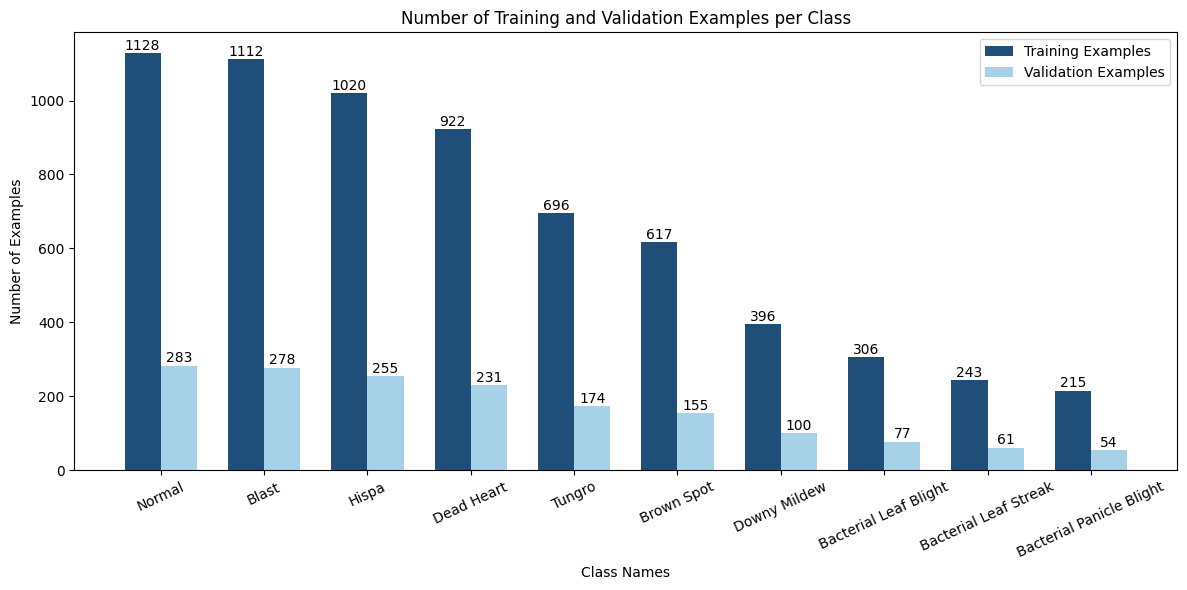

In [82]:
# create a bar chart to compare the number of training examples and validation examples for each class. The x-axis should be the class names and the y-axis should be the number of examples. The bars for training examples should be blue and the bars for validation examples should be orange. The title of the chart should be "Number of Training and Validation Examples per Class"
# order the bar chart by the number of training examples in descending order. Then save the figure as png with high resolution (300 dpi) and tight layout. The file name should be "class_distribution.png".
# order the class names, training counts and validation counts by the number of training examples in descending order
# add number of examples on top of each bar
sorted_indices = np.argsort(train_class_counts)[::-1]
sorted_class_names = [class_names[i] for i in sorted_indices]
sorted_train_counts = [train_class_counts[i] for i in sorted_indices]
sorted_val_counts = [val_class_counts[i] for i in sorted_indices]
x = np.arange(len(class_names))
width = 0.35
plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, sorted_train_counts, width, label="Training Examples", color="#1F4E79")
plt.bar(x + width / 2, sorted_val_counts, width, label="Validation Examples", color="#A6D1E6")
plt.xlabel("Class Names")
plt.ylabel("Number of Examples")
plt.title("Number of Training and Validation Examples per Class")
plt.xticks(x, sorted_class_names, rotation=25)
plt.legend()
for i in range(len(class_names)):
    plt.text(x[i] - width / 2, sorted_train_counts[i] + 1, str(sorted_train_counts[i]), ha="center", va="bottom")
    plt.text(x[i] + width / 2, sorted_val_counts[i] + 1, str(sorted_val_counts[i]), ha="center", va="bottom")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300)
plt.show()



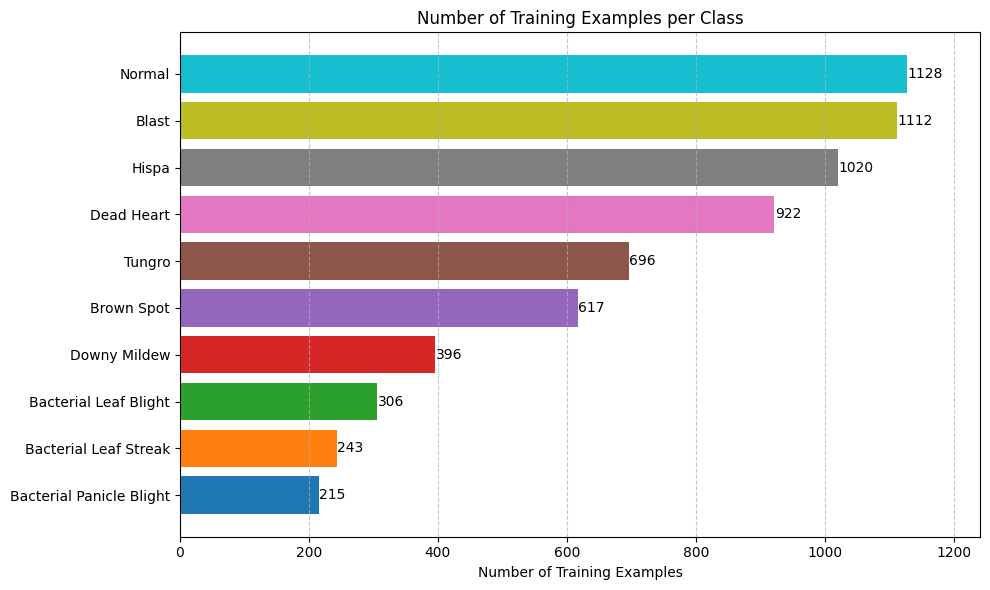

In [16]:
shufflenet_v2_student = ShuffleNetV2(n_class=10, model_size="0.90x")

model size is  0.90x


In [17]:
shufflenet_v2_student.load_state_dict(torch.load("shufflenet_v2_student_extended_2.pth"))
shufflenet_v2_student = shufflenet_v2_student.to(device)

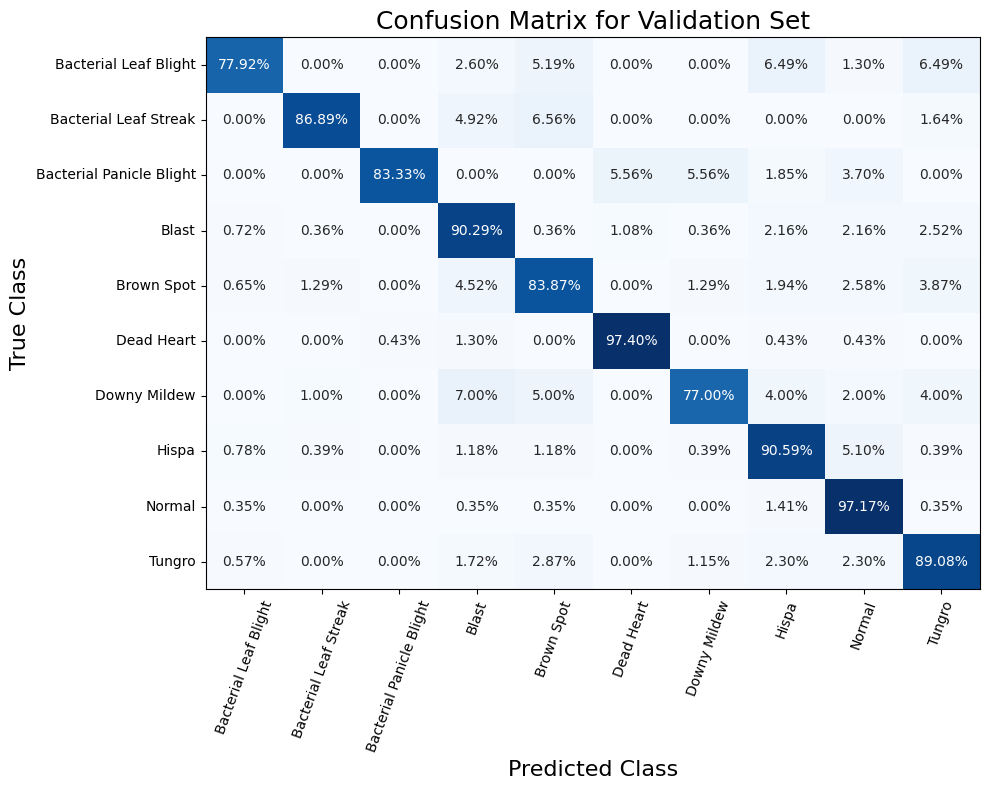

In [114]:
# calculate confusion matrix for validation set, rotate x aixs labels by 60 degrees, and add title "Confusion Matrix for Validation Set". Then save the figure as png with high resolution (300 dpi) and tight layout. The file name should be "confusion_matrix.png".
# use percentage for the confusion matrix values and add color bar. The x-axis should be the predicted class names and the y-axis should be the true class names.

from sklearn.metrics import confusion_matrix
import seaborn as sns
# get true labels and predicted labels for the validation set
true_labels = []
predicted_labels = []
shufflenet_v2_student.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = shufflenet_v2_student(images)
        _, predicted = torch.max(outputs.data, 1)
        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())
# compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix for Validation Set")
plt.xticks(rotation=70)
# ADD THE the border around the confusion matrix
plt.gca().spines["top"].set_visible(True)
plt.gca().spines["right"].set_visible(True)
plt.gca().spines["left"].set_visible(True)
plt.gca().spines["bottom"].set_visible(True)


# there is no need to add heat map color bar legend for the confusion matrix since the values are already annotated in percentage on the heatmap. So we can remove the color bar legend to make the plot cleaner.
plt.gca().collections[0].colorbar.remove()

# add grid lines to the confusion matrix
# set font title size to 18 and the label size to 16
plt.title("Confusion Matrix for Validation Set", fontsize=18)
plt.xlabel("Predicted Class", fontsize=16)
plt.ylabel("True Class", fontsize=16)
# tight layout and save the figure as png with high resolution (300 dpi)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)


plt.show()

In [36]:
# accuracy within each class for validation set
class_correct = [0] * 10
class_total = [0] * 10
shufflenet_v2_student.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = shufflenet_v2_student(images)
        _, predicted = torch.max(outputs.data, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1
class_accuracy = [100 * class_correct[i] / class_total[i] for i in range(10)]
for i in range(10):
    print(f"Accuracy of {class_names[i]}: {class_accuracy[i]:.2f}%")
    

Accuracy of Bacterial Leaf Blight: 77.92%
Accuracy of Bacterial Leaf Streak: 86.89%
Accuracy of Bacterial Panicle Blight: 83.33%
Accuracy of Blast: 90.29%
Accuracy of Brown Spot: 83.87%
Accuracy of Dead Heart: 97.40%
Accuracy of Downy Mildew: 77.00%
Accuracy of Hispa: 90.59%
Accuracy of Normal: 97.17%
Accuracy of Tungro: 89.08%


In [37]:
# number of training exmples per class in the training set
class_counts = [0] * 10
for _, label in train_data:
    class_counts[label] += 1
print("Number of training examples per class:")
for i in range(10):
    print(f"{class_names[i]}: {class_counts[i]}")
    

Number of training examples per class:
Bacterial Leaf Blight: 306
Bacterial Leaf Streak: 243
Bacterial Panicle Blight: 215
Blast: 1112
Brown Spot: 617
Dead Heart: 922
Downy Mildew: 396
Hispa: 1020
Normal: 1128
Tungro: 696
